## ML Model
### The model will be trained on the UCI Credit Card Default dataset that contains information on customer demographics, payment history, and billing history.

### Step 1 - Prepare dataset
#### 1.1 - Import libraries. Copy and paste the following code into the code cell and select Run.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from time import sleep, gmtime, strftime
import json
import time
import sys
import boto3
import sagemaker
from sagemaker import get_execution_role

#### 1.2 - Import the experiments. 

In [2]:
!pip install -qU sagemaker-experiments 
from sagemaker.analytics import ExperimentAnalytics
from smexperiments.experiment import Experiment
from smexperiments.trial import Trial
from smexperiments.trial_component import TrialComponent
from smexperiments.tracker import Tracker

#### 1.3 - Define the Amazon S3 buckets and folders for the project. 

In [78]:
sess = sagemaker.Session()

rawbucket= sess.default_bucket() # Alternatively you can use our custom bucket here. 

prefix = 'sagemaker-modelmonitor' # use this prefix to store all files pertaining to this workshop.

dataprefix = prefix + '/data'
traindataprefix = prefix + '/train_data'
validdataprefix = prefix + '/HPO'
testdataprefix = prefix + '/test_data'
testdatanolabelprefix = prefix + '/test_data_no_label'
trainheaderprefix = prefix + '/train_headers'

#### 1.4 - Get the dataset and import it using the pandas library. 

In [79]:
data = pd.read_excel('./data/default of credit card clients.xls', header=1)
data = data.drop(columns = ['ID'])
data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


#### 1.5 - Rename the last column as Label and extract the label column separately. For the Amazon SageMaker built-in XGBoost algorithm, the label column must be the first column in the dataframe.


In [80]:
data.rename(columns={"default payment next month": "Label"}, inplace=True)
lbl = data.Label
data = pd.concat([lbl, data.drop(columns=['Label'])], axis = 1)
data.head()

,Label,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1,20000,2,2,1,24,2,2,-1,-1,...,689,0,0,0,0,689,0,0,0,0
1,1,120000,2,2,2,26,-1,2,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,0,90000,2,2,2,34,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,0,50000,2,2,1,37,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,0,50000,1,2,1,57,-1,0,-1,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


#### 1.6 - Upload the CSV dataset into an Amazon S3 bucket.

In [81]:
if not os.path.exists('rawdata/rawdata.csv'):
    !mkdir rawdata
    data.to_csv('rawdata/rawdata.csv', index=None)
else:
    pass
# Upload the raw dataset
raw_data_location = sess.upload_data('rawdata', bucket=rawbucket, key_prefix=dataprefix)
print(raw_data_location)

s3://sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/data


### Step 2 - Process the data using Amazon SageMaker Processing

#### In this step, we use Amazon SageMaker Processing to pre-process the dataset, including scaling the columns and splitting the dataset into train and test data. 
#### Amazon SageMaker Processing lets us run preprocessing, postprocessing, and model evaluation workloads on fully managed infrastructure.
#### Complete the following steps to processs the data and generate features using Amazon SageMaker Processing.
##### Note: Amazon SageMaker Processing runs on separate compute instances from your notebook. This means you can continue to experiment and run code in your notebook while the processing job is under way. 
##### This will incur additional charges for the cost of the instance which is up and running for the duration of the processing job. The instances are automatically terminated by SageMaker once the processing job completes.

#### 2.1 - Import the scikit-learn processing container. 

In [82]:
from sagemaker.sklearn.processing import SKLearnProcessor
sklearn_processor = SKLearnProcessor(framework_version='0.20.0',
                                     role=get_execution_role(),
                                     instance_type='ml.c4.xlarge',
                                     instance_count=1)

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Defaulting to only available Python version: py3


#### 2.2 - Creating preprocessing.py file

In [83]:
%%writefile preprocessing.py

import argparse
import os
import warnings

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.exceptions import DataConversionWarning
from sklearn.compose import make_column_transformer

warnings.filterwarnings(action='ignore', category=DataConversionWarning)

if __name__=='__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--train-test-split-ratio', type=float, default=0.3)
    parser.add_argument('--random-split', type=int, default=0)
    args, _ = parser.parse_known_args()
    
    print('Received arguments {}'.format(args))

    input_data_path = os.path.join('/opt/ml/processing/input', 'rawdata.csv')
    
    print('Reading input data from {}'.format(input_data_path))
    df = pd.read_csv(input_data_path)
    df.sample(frac=1)
    
    COLS = df.columns
    newcolorder = ['PAY_AMT1','BILL_AMT1'] + list(COLS[1:])[:11] + list(COLS[1:])[12:17] + list(COLS[1:])[18:]
    
    split_ratio = args.train_test_split_ratio
    random_state=args.random_split
    
    X_train, X_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], 
                                                        test_size=split_ratio, random_state=random_state)
    
    preprocess = make_column_transformer(
        (['PAY_AMT1'], StandardScaler()),
        (['BILL_AMT1'], MinMaxScaler()),
    remainder='passthrough')
    
    print('Running preprocessing and feature engineering transformations')
    train_features = pd.DataFrame(preprocess.fit_transform(X_train), columns = newcolorder)
    test_features = pd.DataFrame(preprocess.transform(X_test), columns = newcolorder)
    
    # concat to ensure Label column is the first column in dataframe
    train_full = pd.concat([pd.DataFrame(y_train.values, columns=['Label']), train_features], axis=1)
    test_full = pd.concat([pd.DataFrame(y_test.values, columns=['Label']), test_features], axis=1)
    
    print('Train data shape after preprocessing: {}'.format(train_features.shape))
    print('Test data shape after preprocessing: {}'.format(test_features.shape))
    
    train_features_headers_output_path = os.path.join('/opt/ml/processing/train_headers', 'train_data_with_headers.csv')
    
    train_features_output_path = os.path.join('/opt/ml/processing/train', 'train_data.csv')
    
    test_features_output_path = os.path.join('/opt/ml/processing/test', 'test_data.csv')
    
    print('Saving training features to {}'.format(train_features_output_path))
    train_full.to_csv(train_features_output_path, header=False, index=False)
    print("Complete")
    
    print("Save training data with headers to {}".format(train_features_headers_output_path))
    train_full.to_csv(train_features_headers_output_path, index=False)
                 
    print('Saving test features to {}'.format(test_features_output_path))
    test_full.to_csv(test_features_output_path, header=False, index=False)
    print("Complete")

Overwriting preprocessing.py


#### 2.3 - Copy the preprocessing code over to the s3 bucket


In [84]:
codeprefix = prefix + '/code'
codeupload = sess.upload_data('preprocessing.py', bucket=rawbucket, key_prefix=codeprefix)
print(codeupload)

s3://sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/code/preprocessing.py


#### 2.4 - Specify where you want to store your training and test data after the SageMaker Processing job completes. Amazon SageMaker Processing automatically stores the data in the specified location.

In [92]:
train_data_location = rawbucket + '/' + traindataprefix
validation = rawbucket + '/' + traindataprefix
test_data_location = rawbucket+'/'+testdataprefix
print("Training data location = {}".format(train_data_location))
print("HPO location = {}".format(validation))
print("Test data location = {}".format(test_data_location))

Training data location = sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/train_data
HPO location = sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/train_data
Test data location = sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/test_data


#### 2.5 - Copy and paste the following code to start the Processing job. This code starts the job by calling sklearn_processor.run and extracts some optional metadata about the processing job, such as where the training and test outputs were stored.

In [93]:
from sagemaker.processing import ProcessingInput, ProcessingOutput

sklearn_processor.run(code=codeupload,
                      inputs=[ProcessingInput(
                        source=raw_data_location,
                        destination='/opt/ml/processing/input')],
                      outputs=[ProcessingOutput(output_name='train_data',
                                                source='/opt/ml/processing/train',
                               destination='s3://' + train_data_location),
                               ProcessingOutput(output_name='test_data',
                                                source='/opt/ml/processing/test',
                                               destination="s3://"+test_data_location),
                               ProcessingOutput(output_name='train_data_headers',
                                                source='/opt/ml/processing/train_headers',
                                               destination="s3://" + rawbucket + '/' + prefix + '/train_headers')],
                      arguments=['--train-test-split-ratio', '0.2']
                     )

preprocessing_job_description = sklearn_processor.jobs[-1].describe()

output_config = preprocessing_job_description['ProcessingOutputConfig']
for output in output_config['Outputs']:
    if output['OutputName'] == 'train_data':
        preprocessed_training_data = output['S3Output']['S3Uri']
    if output['OutputName'] == 'test_data':
        preprocessed_test_data = output['S3Output']['S3Uri']

INFO:sagemaker:Creating processing-job with name sagemaker-scikit-learn-2021-06-14-16-13-23-595



Job Name:  sagemaker-scikit-learn-2021-06-14-16-13-23-595
Inputs:  [{'InputName': 'input-1', 'AppManaged': False, 'S3Input': {'S3Uri': 's3://sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/data', 'LocalPath': '/opt/ml/processing/input', 'S3DataType': 'S3Prefix', 'S3InputMode': 'File', 'S3DataDistributionType': 'FullyReplicated', 'S3CompressionType': 'None'}}, {'InputName': 'code', 'AppManaged': False, 'S3Input': {'S3Uri': 's3://sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/code/preprocessing.py', 'LocalPath': '/opt/ml/processing/input/code', 'S3DataType': 'S3Prefix', 'S3InputMode': 'File', 'S3DataDistributionType': 'FullyReplicated', 'S3CompressionType': 'None'}}]
Outputs:  [{'OutputName': 'train_data', 'AppManaged': False, 'S3Output': {'S3Uri': 's3://sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/train_data', 'LocalPath': '/opt/ml/processing/train', 'S3UploadMode': 'EndOfJob'}}, {'OutputName': 'test_data', 'AppManaged': False, 'S3Output': {'S3Uri':

### Step 3 - Create an Amazon SageMaker Experiment

#### 3.1 - Now that you have downloaded and staged your dataset in Amazon S3, you can create an Amazon SageMaker Experiment. 
#### An experiment is a collection of processing and training jobs related to the same machine learning project. Amazon SageMaker Experiments automatically manages and tracks your training runs for you.

In [94]:
sm = boto3.Session().client('sagemaker')

# Create a SageMaker Experiment
cc_experiment = Experiment.create(
    experiment_name=f"Build-train-deploy-{int(time.time())}", 
    description="Predict credit card default from payments data", 
    sagemaker_boto_client=sm)
print(cc_experiment)

Experiment(sagemaker_boto_client=<botocore.client.SageMaker object at 0x7f3434ac4610>,experiment_name='Build-train-deploy-1623687516',description='Predict credit card default from payments data',tags=None,experiment_arn='arn:aws:sagemaker:eu-central-1:310766717595:experiment/build-train-deploy-1623687516',response_metadata={'RequestId': 'e8bfc091-6698-455c-8045-b0faacbd52f4', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'e8bfc091-6698-455c-8045-b0faacbd52f4', 'content-type': 'application/x-amz-json-1.1', 'content-length': '104', 'date': 'Mon, 14 Jun 2021 16:18:35 GMT'}, 'RetryAttempts': 0})


#### Every training job is logged as a trial. Each trial is an iteration of your end-to-end training job. In addition to the training job, it can also track pre-processing and post-processing jobs as well as datasets and other metadata. A single experiment can include multiple trials which makes it easy for you to track multiple iterations over time within the Amazon SageMaker Studio Experiments pane.

In [95]:
# Start Tracking parameters used in the Pre-processing pipeline.
with Tracker.create(display_name="Preprocessing", sagemaker_boto_client=sm) as tracker:
    tracker.log_parameters({
        "train_test_split_ratio": 0.2,
        "random_state":0
    })
    # we can log the s3 uri to the dataset we just uploaded
    tracker.log_input(name="ccdefault-raw-dataset", media_type="s3/uri", value=raw_data_location)
    tracker.log_input(name="ccdefault-train-dataset", media_type="s3/uri", value=train_data_location)
    tracker.log_input(name="ccdefault-HPO", media_type="s3/uri", value=validation)
    tracker.log_input(name="ccdefault-test-dataset", media_type="s3/uri", value=test_data_location)

#### To train an XGBoost classifier, you first import the XGBoost container maintained by Amazon SageMaker. Then, you log the training run under a Trial so SageMaker Experiments can track it under a Trial name. The pre-processing job is included under the same trial name since it is part of the pipeline. Next, create a SageMaker Estimator object, which automatically provisions the underlying instance type of your choosing, copies over the training data from the specified output location from the processing job, trains the model, and outputs the model artifacts.

In [96]:
from sagemaker.amazon.amazon_estimator import get_image_uri
from sagemaker.tuner import (
    IntegerParameter,
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner,
)
container = get_image_uri(boto3.Session().region_name, 'xgboost', '1.0-1')
s3_input_train = sagemaker.TrainingInput(s3_data='s3://' + train_data_location, content_type='csv')
s3_input_validation = sagemaker.TrainingInput(s3_data="s3://"+validation, content_type="csv")
preprocessing_trial_component = tracker.trial_component

trial_name = f"cc-default-training-job-{int(time.time())}"
cc_trial = Trial.create(
        trial_name=trial_name, 
            experiment_name=cc_experiment.experiment_name,
        sagemaker_boto_client=sm
    )

cc_trial.add_trial_component(preprocessing_trial_component)
cc_training_job_name = "cc-training-job-{}".format(int(time.time()))

xgb = sagemaker.estimator.Estimator(container,
                                    get_execution_role(), 
                                    train_instance_count=1, 
                                    train_instance_type='ml.m4.xlarge',
                                    train_max_run=86400,
                                    output_path='s3://{}/{}/models'.format(rawbucket, prefix),
                                    sagemaker_session=sess) # set to true for distributed training

xgb.set_hyperparameters(eval_metric="auc",
                        objective="binary:logistic",
                        num_round=100,
                        rate_drop=0.3,
                        tweedie_variance_power=1.4)

objective_metric_name = 'validation:auc'

# Log scaling
hyperparameter_ranges = {
    "alpha": ContinuousParameter(0.01, 10, scaling_type="Logarithmic"),
    "lambda": ContinuousParameter(0.01, 10, scaling_type="Logarithmic"),
}

# Random search
tuner_log = HyperparameterTuner(
    xgb,
    objective_metric_name,
    hyperparameter_ranges,
    max_jobs=4,
    max_parallel_jobs=4,
    strategy="Random",
)


See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker.image_uris:Defaulting to only supported image scope: cpu.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


In [97]:
s3_input_validation

In [98]:
# tuner_log.fit(inputs = {'train':s3_input_train},
#        job_name=cc_training_job_name,
#         experiment_config={
#             "TrialName": cc_trial.trial_name, #log training job in Trials for lineage
#             "TrialComponentDisplayName": "Training",
#         },
#         wait=True,
#     )
tuner_log.fit(
    {"train": s3_input_train, "validation": s3_input_validation}, include_cls_metadata=False
)
time.sleep(2)

INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-210614-1619


........................................................!


In [103]:
hyperparameter_ranges_linear = {
    "alpha": ContinuousParameter(0.01, 10, scaling_type="Linear"),
    "lambda": ContinuousParameter(0.01, 10, scaling_type="Linear"),
}

tuner_linear = HyperparameterTuner(
    xgb,
    objective_metric_name,
    hyperparameter_ranges_linear,
    max_jobs=4,
    max_parallel_jobs=4,
    strategy="Random",
)

# custom job name to avoid a duplicate name
# job_name = tuner_linear.latest_tuning_job.job_name + "linear"
# tuner_linear.fit(
#     inputs = {'train':s3_input_train},
#        job_name=job_name,
#         experiment_config={
#             "TrialName": cc_trial.trial_name, #log training job in Trials for lineage
#             "TrialComponentDisplayName": "Training",
#         },
#         wait=True,
# )
tuner_linear.fit(
    {"train": s3_input_train, "validation": s3_input_validation}, include_cls_metadata=False
)
time.sleep(2)

INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-210614-1627


........................................................!


### Step 4: Deploy the model for offline inference

#### In your preprocessing step, you generated some test data. In this step, you generate offline or batch inference from the trained model to evaluate the model performance on unseen test data.

##### 4.1 - This step copies the test dataset over from the Amazon S3 location into your local folder. 

In [104]:
test_data_path = 's3://' + test_data_location + '/test_data.csv'
! aws s3 cp $test_data_path .

download: s3://sagemaker-eu-central-1-310766717595/sagemaker-modelmonitor/test_data/test_data.csv to ./test_data.csv


In [105]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# check jobs have finished
status_log = boto3.client("sagemaker").describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuner_log.latest_tuning_job.job_name
)["HyperParameterTuningJobStatus"]
status_linear = boto3.client("sagemaker").describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuner_linear.latest_tuning_job.job_name
)["HyperParameterTuningJobStatus"]

assert status_log == "Completed", "First must be completed, was {}".format(status_log)
assert status_linear == "Completed", "Second must be completed, was {}".format(status_linear)

df_log = sagemaker.HyperparameterTuningJobAnalytics(
    tuner_log.latest_tuning_job.job_name
).dataframe()
df_linear = sagemaker.HyperparameterTuningJobAnalytics(
    tuner_linear.latest_tuning_job.job_name
).dataframe()
df_log["scaling"] = "log"
df_linear["scaling"] = "linear"
df = pd.concat([df_log, df_linear], ignore_index=True)

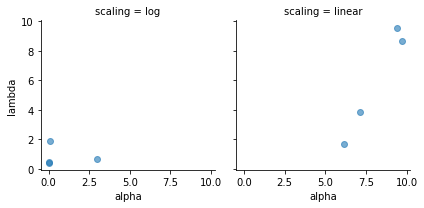

In [106]:
g = sns.FacetGrid(df, col="scaling", palette="viridis")
g = g.map(plt.scatter, "alpha", "lambda", alpha=0.6)

In [107]:
df

,alpha,lambda,TrainingJobName,TrainingJobStatus,FinalObjectiveValue,TrainingStartTime,TrainingEndTime,TrainingElapsedTimeSeconds,scaling
0,0.025672,0.480239,sagemaker-xgboost-210614-1619-004-a1dd099c,Completed,0.93278,2021-06-14 16:21:50+00:00,2021-06-14 16:23:35+00:00,105.0,log
1,0.054871,0.413111,sagemaker-xgboost-210614-1619-003-5071ed64,Completed,0.93928,2021-06-14 16:21:47+00:00,2021-06-14 16:23:09+00:00,82.0,log
2,0.115856,1.879484,sagemaker-xgboost-210614-1619-002-346b6cff,Completed,0.93716,2021-06-14 16:21:48+00:00,2021-06-14 16:23:05+00:00,77.0,log
3,2.953181,0.659073,sagemaker-xgboost-210614-1619-001-20dedfa9,Completed,0.94120,2021-06-14 16:21:45+00:00,2021-06-14 16:23:09+00:00,84.0,log
4,6.152901,1.705177,sagemaker-xgboost-210614-1627-004-1af6dd97,Completed,0.92401,2021-06-14 16:29:44+00:00,2021-06-14 16:31:27+00:00,103.0,linear
5,9.686961,8.628156,sagemaker-xgboost-210614-1627-003-07e5b9c2,Completed,0.89491,2021-06-14 16:29:39+00:00,2021-06-14 16:31:01+00:00,82.0,linear
6,7.153902,3.855932,sagemaker-xgboost-210614-1627-002-151f175a,Completed,0.91397,2021-06-14 16:30:21+00:00,2021-06-14 16:31:45+00:00,84.0,linear
7,9.401489,9.563340,sagemaker-xgboost-210614-1627-001-7a8807ab,Completed,0.89545,2021-06-14 16:29:41+00:00,2021-06-14 16:31:04+00:00,83.0,linear


In [108]:
test_full = pd.read_csv('test_data.csv', names = [str(x) for x in range(len(data.columns))])
test_full.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0,-0.341476,0.201175,20000.0,1.0,1.0,2.0,33.0,1.0,2.0,...,17399.0,19057.0,18453.0,19755.0,19288.0,2260.0,0.0,1600.0,0.0,644.0
1,0,-0.136859,0.199594,20000.0,2.0,2.0,2.0,35.0,0.0,0.0,...,19347.0,18600.0,19000.0,19000.0,20000.0,0.0,1000.0,0.0,1000.0,0.0
2,0,-0.284364,0.185736,230000.0,2.0,1.0,1.0,44.0,1.0,-1.0,...,949.0,2864.0,933.0,0.0,0.0,2873.0,933.0,0.0,0.0,0.0
3,0,-0.040569,0.289360,100000.0,1.0,2.0,1.0,42.0,0.0,0.0,...,99998.0,16138.0,17758.0,18774.0,20272.0,2000.0,2000.0,2000.0,2000.0,2000.0
4,0,0.079132,0.186502,150000.0,1.0,1.0,2.0,29.0,-2.0,-2.0,...,6917.0,831.0,6469.0,5138.0,7810.0,833.0,6488.0,5153.0,7833.0,7130.0


In [109]:
label = test_full['0'] 

In [110]:
boto3.client("sagemaker").describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuner_log.latest_tuning_job.job_name
)["HyperParameterTuningJobStatus"]

'Completed'

#### Like the training job, SageMaker provisions all the underlying resources, copies over the trained model artifacts, sets up a Batch endpoint locally, copies over the data, and runs inferences on the data and pushes the outputs to Amazon S3. Note that by setting the input_filter, you are letting Batch Transform know to neglect the first column in the test data which is the label column.

In [115]:
tuner_linear.deploy(initial_instance_count=1, instance_type='ml.m4.xlarge')


2021-06-14 16:31:27 Starting - Preparing the instances for training
2021-06-14 16:31:27 Downloading - Downloading input data
2021-06-14 16:31:27 Training - Training image download completed. Training in progress.
2021-06-14 16:31:27 Uploading - Uploading generated training model
2021-06-14 16:31:27 Completed - Training job completed

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2021-06-14-16-45-26-563


INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-210614-1627-004-1af6dd97


---------------!

In [117]:
%%time

sm_transformer = xgb.transformer(1, 'ml.m5.xlarge', accept = 'text/csv', model_name='sagemaker-xgboost-2021-06-14-16-45-26-563')

# start a transform job
sm_transformer.transform(test_data_path, split_type='Line', input_filter='$[1:]', content_type='text/csv')
sm_transformer.wait()



INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2021-06-14-17-10-05-017


..........................[2021-06-14:17:14:06:INFO] No GPUs detected (normal if no gpus installed)
[2021-06-14:17:14:06:INFO] No GPUs detected (normal if no gpus installed)
[2021-06-14:17:14:06:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;

worker_rlimit_nofile 4096;

events {
  worker_connections 2048;
}

[2021-06-14:17:14:06:INFO] No GPUs detected (normal if no gpus installed)
[2021-06-14:17:14:06:INFO] No GPUs detected (normal if no gpus installed)
[2021-06-14:17:14:06:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;

worker_rlimit_nofile 4096;

events {
  worker_connections 2048;
}

http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;

  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }

  server {
    listen 8080 deferred;
    client_max_body_size 0;

    keepalive_timeout 3;

    location ~ ^/(ping|invoc

#### First, you define a function that pulls the output of the Batch Transform job, which is contained in a file with a .out extension from the Amazon S3 bucket. Then, you extract the predicted labels into a dataframe and append the true labels to this dataframe.

In [119]:
import json
import io
from urllib.parse import urlparse

def get_csv_output_from_s3(s3uri, file_name):
    parsed_url = urlparse(s3uri)
    bucket_name = parsed_url.netloc
    prefix = parsed_url.path[1:]
    s3 = boto3.resource('s3')
    obj = s3.Object(bucket_name, '{}/{}'.format(prefix, file_name))
    return obj.get()["Body"].read().decode('utf-8')
output = get_csv_output_from_s3(sm_transformer.output_path, 'test_data.csv.out')
output_df = pd.read_csv(io.StringIO(output), sep=",", header=None)
output_df.head(8)
output_df['Predicted']=np.round(output_df.values)
output_df['Label'] = label
from sklearn.metrics import confusion_matrix, accuracy_score
confusion_matrix = pd.crosstab(output_df['Predicted'], output_df['Label'], rownames=['Actual'], colnames=['Predicted'], margins = True)
confusion_matrix

Predicted,0,1,All
Actual,,,
0.0,4473,811,5284
1.0,230,486,716
All,4703,1297,6000


#### Use the following code to extract both the baseline model accuracy and the model accuracy.

In [120]:
print("Baseline Accuracy = {}".format(1- np.unique(data['Label'], return_counts=True)[1][1]/(len(data['Label']))))
print("Accuracy Score = {}".format(accuracy_score(label, output_df['Predicted'])))

Baseline Accuracy = 0.7787999999999999
Accuracy Score = 0.8265


##### The results show that a simple model can already beat the baseline accuracy. In order to improve the results, you can tune the hyperparameters.

### Step 5 - Deploy the model as an endpoint and set up data capture

#### In this step, you deploy the model as a RESTful HTTPS endpoint to serve live inferences. Amazon SageMaker automatically handles the model hosting and creation of the endpoint for you.

In [121]:
from sagemaker.model_monitor import DataCaptureConfig
from sagemaker import RealTimePredictor
from sagemaker.predictor import csv_serializer

sm_client = boto3.client('sagemaker')

latest_training_job = sm_client.list_training_jobs(MaxResults=1,
                                                SortBy='CreationTime',
                                                SortOrder='Descending')

training_job_name=TrainingJobName=latest_training_job['TrainingJobSummaries'][0]['TrainingJobName']

training_job_description = sm_client.describe_training_job(TrainingJobName=training_job_name)

model_data = training_job_description['ModelArtifacts']['S3ModelArtifacts']
container_uri = training_job_description['AlgorithmSpecification']['TrainingImage']

# create a model.
def create_model(role, model_name, container_uri, model_data):
    return sm_client.create_model(
        ModelName=model_name,
        PrimaryContainer={
        'Image': container_uri,
        'ModelDataUrl': model_data,
        },
        ExecutionRoleArn=get_execution_role())
    

try:
    model = create_model(get_execution_role(), training_job_name, container_uri, model_data)
except Exception as e:
        sm_client.delete_model(ModelName=training_job_name)
        model = create_model(get_execution_role(), training_job_name, container_uri, model_data)
        

print('Model created: '+model['ModelArn'])


ImportError: cannot import name 'RealTimePredictor' from 'sagemaker' (/opt/conda/lib/python3.7/site-packages/sagemaker/__init__.py)

#### This code tells SageMaker to capture 100% of the inference payloads received by the endpoint, capture both inputs and outputs, and also note the input content type as csv.

In [41]:
s3_capture_upload_path = 's3://{}/{}/monitoring/datacapture'.format(rawbucket, prefix)
data_capture_configuration = {
    "EnableCapture": True,
    "InitialSamplingPercentage": 100,
    "DestinationS3Uri": s3_capture_upload_path,
    "CaptureOptions": [
        { "CaptureMode": "Output" },
        { "CaptureMode": "Input" }
    ],
    "CaptureContentTypeHeader": {
       "CsvContentTypes": ["text/csv"],
       "JsonContentTypes": ["application/json"]}}

#### This step creates an endpoint configuration and deploys the endpoint. In the code, you can specify instance type and whether you want to send all the traffic to this endpoint, etc.

In [42]:
def create_endpoint_config(model_config, data_capture_config): 
    return sm_client.create_endpoint_config(
                                                EndpointConfigName=model_config,
                                                ProductionVariants=[
                                                        {
                                                            'VariantName': 'AllTraffic',
                                                            'ModelName': model_config,
                                                            'InitialInstanceCount': 1,
                                                            'InstanceType': 'ml.m4.xlarge',
                                                            'InitialVariantWeight': 1.0,
                                                },
                                                    
                                                    ],
                                                DataCaptureConfig=data_capture_config
                                                )




try:
    endpoint_config = create_endpoint_config(training_job_name, data_capture_configuration)
except Exception as e:
    sm_client.delete_endpoint_config(EndpointConfigName=endpoint)
    endpoint_config = create_endpoint_config(training_job_name, data_capture_configuration)

print('Endpoint configuration created: '+ endpoint_config['EndpointConfigArn'])

Endpoint configuration created: arn:aws:sagemaker:eu-central-1:310766717595:endpoint-config/cc-training-job-1616511663


In [43]:
# Enable data capture, sampling 100% of the data for now. Next we deploy the endpoint in the correct VPC.

endpoint_name = training_job_name
def create_endpoint(endpoint_name, config_name):
    return sm_client.create_endpoint(
                                    EndpointName=endpoint_name,
                                    EndpointConfigName=training_job_name
                                )


try:
    endpoint = create_endpoint(endpoint_name, endpoint_config)
except Exception as e:
    sm_client.delete_endpoint(EndpointName=endpoint_name)
    endpoint = create_endpoint(endpoint_name, endpoint_config)

print('Endpoint created: '+ endpoint['EndpointArn'])

Endpoint created: arn:aws:sagemaker:eu-central-1:310766717595:endpoint/cc-training-job-1616511663


In [44]:
!head -10 test_data.csv > test_sample.csv

In [47]:
from sagemaker import RealTimePredictor
from sagemaker.predictor import csv_serializer

predictor = RealTimePredictor(endpoint=endpoint_name, content_type = 'text/csv')

with open('test_sample.csv', 'r') as f:
    for row in f:
        payload = row.rstrip('\n')
        response = predictor.predict(data=payload[2:])
        sleep(0.5)
print('done!')

done!


In [51]:
# Extract the captured json files.
data_capture_prefix = '{}/monitoring'.format(prefix)
s3_client = boto3.Session().client('s3')
current_endpoint_capture_prefix = '{}/datacapture/{}/AllTraffic'.format(data_capture_prefix, endpoint_name)
print(current_endpoint_capture_prefix)
result = s3_client.list_objects(Bucket=rawbucket, Prefix=current_endpoint_capture_prefix)
capture_files = [capture_file.get("Key") for capture_file in result.get('Contents')]
print("Found Capture Files:")
print("\n ".join(capture_files))


capture_files[0]

sagemaker-modelmonitor/monitoring/datacapture/cc-training-job-1616511663/AllTraffic
Found Capture Files:
sagemaker-modelmonitor/monitoring/datacapture/cc-training-job-1616511663/AllTraffic/2021/03/24/12/18-21-421-b652b121-1af9-40e1-b916-31bc09021630.jsonl


'sagemaker-modelmonitor/monitoring/datacapture/cc-training-job-1616511663/AllTraffic/2021/03/24/12/18-21-421-b652b121-1af9-40e1-b916-31bc09021630.jsonl'

In [52]:
# View contents of the captured file.
def get_obj_body(bucket, obj_key):
    return s3_client.get_object(Bucket=rawbucket, Key=obj_key).get('Body').read().decode("utf-8")

capture_file = get_obj_body(rawbucket, capture_files[0])
print(json.dumps(json.loads(capture_file.split('\n')[5]), indent = 2, sort_keys =True))


{
  "captureData": {
    "endpointInput": {
      "data": "-0.34147611300851444,0.1932005252116958,50000.0,1.0,2.0,2.0,25.0,-1.0,3.0,2.0,0.0,0.0,0.0,10386.0,9993.0,9993.0,15300.0,0.0,0.0,200.0,5307.0,0.0,0.0",
      "encoding": "CSV",
      "mode": "INPUT",
      "observedContentType": "text/csv"
    },
    "endpointOutput": {
      "data": "0.5108723044395447",
      "encoding": "CSV",
      "mode": "OUTPUT",
      "observedContentType": "text/csv; charset=utf-8"
    }
  },
  "eventMetadata": {
    "eventId": "6e4e3e53-bcf6-4f57-8365-e3d36912d004",
    "inferenceTime": "2021-03-24T12:18:24Z"
  },
  "eventVersion": "0"
}
